# NLP Case study 1 

## NB model with Unigram+CountVectors	 

**Config of the model trained**

Train Time = 0.31 seconds	

**Training Data Check**	

Confusion Matrix Built - Yes

F1 Score for Positive = 0.9249

F1 Score for Negative = 0.7760

AUC plotted - Yes

AUC = 0.9477	

Accuracy computed - Yes	

Accuracy = 0.8541

**Feature Engg**

Categorical/Numerical Features Added - Yes	

Name 2 features added - review_length and word_count 

Cross Validation - Yes (0.80)	 	 	 
 
**Interpretability**	

Interpretability Implemented? - Yes, Local	

2 interesting findings? 

-world cloud for positive and negative reviews

-Top 10 positive and negative reviews 
                 
**Testing Data Check** 	

Confusion Matrix Built - Yes

F1 Score for Positive = 0.8964

F1 Score for Negative = 0.7340

AUC plotted - Yes	

AUC = 0.9047

Accuracy computed - Yes

Accuracy = 0.8065

In [1]:
import random
import json
import pandas as pd

# File path
file_path = '/Users/maaz/Desktop/NLP Assignment/Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json'

# Function to sample data from JSON
def sample_json(file_path, sample_size):
    sampled_data = []
    with open(file_path, 'r') as file:
        # Read all lines from the file
        lines = file.readlines()
        # Randomly sample lines
        sampled_lines = random.sample(lines, sample_size)
        for line in sampled_lines:
            # Parse each line as JSON and extract necessary fields
            record = json.loads(line)
            sampled_data.append({"text": record["text"], "stars": record["stars"]})
    return pd.DataFrame(sampled_data)

# Get a random sample of 10,000 rows
sample_size = 20000
sampled_data = sample_json(file_path, sample_size)

# Preview the sample
print(sampled_data.head())

# Save the sample to a CSV file for easier reuse (optional)
sampled_data.to_csv('/Users/maaz/Desktop/NLP Assignment/yelp_sample_20k.csv', index=False)



                                                text  stars
0  We really enjoyed their use of homemade ingred...    5.0
1  We moved to Sarasota and upon many recommendat...    5.0
2  Very disappointed in today's meal. The wife an...    2.0
3  I wish I could reward the store w 5 stars, pro...    4.0
4  Came here for brunch yesterday, it goes till 3...    5.0


## 1. Naive Bayes model using Count Vectors for Unigram

**Build the following models to predict whether a given review is Positive (4 or 5 stars), Negative (2 or less stars) or Neutral on the Yelp Dataset**

In [4]:
# import all necessary libraries

import pandas as pd 
import numpy as np 
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Download necessary NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /Users/maaz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/maaz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/maaz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
# To display all the text 

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [12]:
## import sample dataset

df = pd.read_csv('yelp_sample_20k.csv')

## display top 5 rows 

df.head()

,text,stars
0,We really enjoyed their use of homemade ingredients! Really great meals. A new favorite spot!,5.0
1,"We moved to Sarasota and upon many recommendations decided to go to Tampa to buy furniture. Modani was the store everyone suggested and we were not disappointed.\nJen was fun as well as very professional to work with. We ordered what we needed and subsequently had to cancel an item. No problem. This is a first class operation. Kim, the manager, is so efficient and service-oriented. We look forward to future purchases.",5.0
2,Very disappointed in today's meal. The wife and both got a pasta dish. Both were watered downed and had little to no flavor. My dish was a shrimp and chicken pasta. Had 1 piece of shrimp buried in pasta with the tail still on it. Been coming here over two years. This time I was disappointed.,2.0
3,"I wish I could reward the store w 5 stars, product with 4 to 5, and the marketing one star! Great service in this location both times I've been (new to AZ). Love the panties. Do not understand the rationale of an online only Labor Day deal complete w signage in store that the associates have to explain doesn't apply in store! You have people in the store that want to spend money and you are telling them to go home to their computers. Foolish! On the 15 min I was in store two customers left unhappy with NO PURCHASE. Feel bad for assoc\n\nUpdate: very unhappy with wear and diff fit between styles. Will keep searching for a brand that works",4.0
4,"Came here for brunch yesterday, it goes till 3pm which is great if you are a late riser. We sat at the bar and Angelo was our bartender. Love coming here for brunch and have many times. Normally get the same thing but they have changed brunch menus since I had been in there last. Really missed the Eggs Benedict that is no longer on the new menu :( . To get things started my bf had a few mimosas and I had a Bloody Mary (not pictured). Both delicious and the bloody Mary's come topped with cheese, bacon, pickle, lemon, and lime. It was so tasty I dove right in and forgot to snap a pic, oops! Random but we ordered the Calamari to start food wise. It was great and came with Aioli sauce to dip (which I prefer that or some kind of cheese over marinara). For actual brunch we shared their spin on chicken/waffles and the banana pancakes option. The chicken and waffles was a fried buffalo chicken breast over churros, with a side of ranch to dip. Super good as I love anything buffalo and the way they fried the chicken was delicious. This was definitely all gone before the pancakes were. The banana pancakes were the perfect pairing to be the sweeter side. They had a bourbon creamy sauce poured over, bananas, and powdered sugar, with a cup of syrup. My bf ended up having a few Screw Drivers that he drank right up- loved them. I love coming to bars that have ALOT of options on tap. I was able to have a Blue Moon /Angry Orchard combo that is hard to do sometimes. Ended everything on a dessert note by having the S'mores martini! Perfect amount of sweet to cure my sweet tooth! Angelo, our bartender, let us try a sample or 2 of beers we haven't seen before. He took great care of us and was very attentive, even with the brunch rush. Make sure to sit in his section if you make your way here! Great amount of TVs at the bar to catch the game, but not all over place. They also have actual dinning areas if you want a more dinner experience vs a bar experience.",5.0


In [14]:
# To check the shape of the dataset
df.shape

(20000, 2)

In [16]:
def assign_sentiment(stars):
    if stars >= 4:
        return 'Positive'
    elif stars <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['stars'].apply(assign_sentiment)


In [18]:
df.head()

,text,stars,sentiment
0,We really enjoyed their use of homemade ingredients! Really great meals. A new favorite spot!,5.0,Positive
1,"We moved to Sarasota and upon many recommendations decided to go to Tampa to buy furniture. Modani was the store everyone suggested and we were not disappointed.\nJen was fun as well as very professional to work with. We ordered what we needed and subsequently had to cancel an item. No problem. This is a first class operation. Kim, the manager, is so efficient and service-oriented. We look forward to future purchases.",5.0,Positive
2,Very disappointed in today's meal. The wife and both got a pasta dish. Both were watered downed and had little to no flavor. My dish was a shrimp and chicken pasta. Had 1 piece of shrimp buried in pasta with the tail still on it. Been coming here over two years. This time I was disappointed.,2.0,Negative
3,"I wish I could reward the store w 5 stars, product with 4 to 5, and the marketing one star! Great service in this location both times I've been (new to AZ). Love the panties. Do not understand the rationale of an online only Labor Day deal complete w signage in store that the associates have to explain doesn't apply in store! You have people in the store that want to spend money and you are telling them to go home to their computers. Foolish! On the 15 min I was in store two customers left unhappy with NO PURCHASE. Feel bad for assoc\n\nUpdate: very unhappy with wear and diff fit between styles. Will keep searching for a brand that works",4.0,Positive
4,"Came here for brunch yesterday, it goes till 3pm which is great if you are a late riser. We sat at the bar and Angelo was our bartender. Love coming here for brunch and have many times. Normally get the same thing but they have changed brunch menus since I had been in there last. Really missed the Eggs Benedict that is no longer on the new menu :( . To get things started my bf had a few mimosas and I had a Bloody Mary (not pictured). Both delicious and the bloody Mary's come topped with cheese, bacon, pickle, lemon, and lime. It was so tasty I dove right in and forgot to snap a pic, oops! Random but we ordered the Calamari to start food wise. It was great and came with Aioli sauce to dip (which I prefer that or some kind of cheese over marinara). For actual brunch we shared their spin on chicken/waffles and the banana pancakes option. The chicken and waffles was a fried buffalo chicken breast over churros, with a side of ranch to dip. Super good as I love anything buffalo and the way they fried the chicken was delicious. This was definitely all gone before the pancakes were. The banana pancakes were the perfect pairing to be the sweeter side. They had a bourbon creamy sauce poured over, bananas, and powdered sugar, with a cup of syrup. My bf ended up having a few Screw Drivers that he drank right up- loved them. I love coming to bars that have ALOT of options on tap. I was able to have a Blue Moon /Angry Orchard combo that is hard to do sometimes. Ended everything on a dessert note by having the S'mores martini! Perfect amount of sweet to cure my sweet tooth! Angelo, our bartender, let us try a sample or 2 of beers we haven't seen before. He took great care of us and was very attentive, even with the brunch rush. Make sure to sit in his section if you make your way here! Great amount of TVs at the bar to catch the game, but not all over place. They also have actual dinning areas if you want a more dinner experience vs a bar experience.",5.0,Positive


## Text Cleaning

In [21]:
# Convert to lowercase
def to_lowercase(text):
    return text.lower()

# Remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Remove stop words
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    tokens = word_tokenize(text)
    return ' '.join([word for word in tokens if word not in stop_words])

# Remove digits
def remove_digits(text):
    return re.sub(r'\d+', '', text)

# Tokenize text
def tokenize_text(text):
    return word_tokenize(text)

# Lemmatization
lemmatizer = WordNetLemmatizer()
def apply_lemmatization(text):
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

In [23]:
# Apply cleaning functions
df['cleaned_text'] = df['text'].apply(to_lowercase)\
                               .apply(remove_punctuation)\
                               .apply(remove_digits)\
                               .apply(remove_stopwords)\
                               .apply(apply_lemmatization)

In [25]:
df.head()

,text,stars,sentiment,cleaned_text
0,We really enjoyed their use of homemade ingredients! Really great meals. A new favorite spot!,5.0,Positive,really enjoyed use homemade ingredient really great meal new favorite spot
1,"We moved to Sarasota and upon many recommendations decided to go to Tampa to buy furniture. Modani was the store everyone suggested and we were not disappointed.\nJen was fun as well as very professional to work with. We ordered what we needed and subsequently had to cancel an item. No problem. This is a first class operation. Kim, the manager, is so efficient and service-oriented. We look forward to future purchases.",5.0,Positive,moved sarasota upon many recommendation decided go tampa buy furniture modani store everyone suggested disappointed jen fun well professional work ordered needed subsequently cancel item problem first class operation kim manager efficient serviceoriented look forward future purchase
2,Very disappointed in today's meal. The wife and both got a pasta dish. Both were watered downed and had little to no flavor. My dish was a shrimp and chicken pasta. Had 1 piece of shrimp buried in pasta with the tail still on it. Been coming here over two years. This time I was disappointed.,2.0,Negative,disappointed today meal wife got pasta dish watered downed little flavor dish shrimp chicken pasta piece shrimp buried pasta tail still coming two year time disappointed
3,"I wish I could reward the store w 5 stars, product with 4 to 5, and the marketing one star! Great service in this location both times I've been (new to AZ). Love the panties. Do not understand the rationale of an online only Labor Day deal complete w signage in store that the associates have to explain doesn't apply in store! You have people in the store that want to spend money and you are telling them to go home to their computers. Foolish! On the 15 min I was in store two customers left unhappy with NO PURCHASE. Feel bad for assoc\n\nUpdate: very unhappy with wear and diff fit between styles. Will keep searching for a brand that works",4.0,Positive,wish could reward store w star product marketing one star great service location time ive new az love panty understand rationale online labor day deal complete w signage store associate explain doesnt apply store people store want spend money telling go home computer foolish min store two customer left unhappy purchase feel bad assoc update unhappy wear diff fit style keep searching brand work
4,"Came here for brunch yesterday, it goes till 3pm which is great if you are a late riser. We sat at the bar and Angelo was our bartender. Love coming here for brunch and have many times. Normally get the same thing but they have changed brunch menus since I had been in there last. Really missed the Eggs Benedict that is no longer on the new menu :( . To get things started my bf had a few mimosas and I had a Bloody Mary (not pictured). Both delicious and the bloody Mary's come topped with cheese, bacon, pickle, lemon, and lime. It was so tasty I dove right in and forgot to snap a pic, oops! Random but we ordered the Calamari to start food wise. It was great and came with Aioli sauce to dip (which I prefer that or some kind of cheese over marinara). For actual brunch we shared their spin on chicken/waffles and the banana pancakes option. The chicken and waffles was a fried buffalo chicken breast over churros, with a side of ranch to dip. Super good as I love anything buffalo and the way they fried the chicken was delicious. This was definitely all gone before the pancakes were. The banana pancakes were the perfect pairing to be the sweeter side. They had a bourbon creamy sauce poured over, bananas, and powdered sugar, with a cup of syrup. My bf ended up having a few Screw Drivers that he drank right up- loved them. I love coming to bars that have ALOT of options on tap. I was able to have a Blue Moon /Angry Orchard combo that is hard to do sometimes. Ended everything on a dessert note by having 

In [34]:
# Assign features (cleaned text) and target (sentiment)
X = df['cleaned_text']  # Preprocessed text
y = df['sentiment']     # Sentiment (Positive, Negative, Neutral)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Training Time

In [37]:
# Start time to measure training duration
start_time = time.time()

# Initialize CountVectorizer for Unigram
vectorizer = CountVectorizer(ngram_range=(1, 1),max_features=10000)  # Unigram

# Transform the text into Count Vectors
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_vectors, y_train)

# Measure training time
train_time = time.time() - start_time
print(f"Training Time: {train_time:.2f} seconds")


Training Time: 0.31 seconds


In [39]:
# Make predictions on the test set
y_pred = nb_model.predict(X_test_vectors)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

    Negative       0.73      0.74      0.73      1385
     Neutral       0.34      0.39      0.37       551
    Positive       0.91      0.89      0.90      4064

    accuracy                           0.81      6000
   macro avg       0.66      0.67      0.67      6000
weighted avg       0.81      0.81      0.81      6000

Accuracy Score: 0.8065
Confusion Matrix:
 [[1025  223  137]
 [ 106  215  230]
 [ 277  188 3599]]


## Example new review

In [42]:
new_reviews = ["Loved this tour! I grabbed a groupon and the price was great. It was the perfect way to explore New Orleans for someone who'd never been there before and didn't know a lot about the history of the city. Our tour guide had tons of interesting tidbits about the city, and I really enjoyed the experience. Highly recommended tour. I actually thought we were just going to tour through the cemetery, but she took us around the French Quarter for the first hour, and the cemetery for the second half of the tour. You'll meet up in front of a grocery store (seems strange at first, but it's not terribly hard to find, and it'll give you a chance to get some water), and you'll stop at a visitor center part way through the tour for a bathroom break if needed. This tour was one of my favorite parts of my trip!"]
# Preprocess and transform new reviews
new_reviews_vectors = vectorizer.transform(new_reviews)

# Predict sentiment
new_predictions = nb_model.predict(new_reviews_vectors)

print(new_predictions)  # Output: ['Positive', 'Negative', 'Neutral']


['Positive']


## Training data check and Evaluation 

In [47]:
from sklearn.metrics import accuracy_score

# Predict the class labels for training data
y_train_pred = nb_model.predict(X_train_vectors)
y_test_pred = nb_model.predict(X_test_vectors)

# Calculate accuracy for both training and testing data
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Print the accuracy scores
print(f"Accuracy Score (Train): {accuracy_train:.4f}")
print(f"Accuracy Score (Test): {accuracy_test:.4f}")

Accuracy Score (Train): 0.8541
Accuracy Score (Test): 0.8065


In [49]:
# Compute F1 Score for all classes
f1_train = f1_score(y_train, y_train_pred, average='weighted')
print(f"Weighted F1 Score (Train): {f1_train:.4f}")


Weighted F1 Score (Train): 0.8575


In [51]:
f1_pos_train = f1_score(y_train, y_train_pred, labels=['Positive'], average='macro')
f1_neg_train = f1_score(y_train, y_train_pred, labels=['Negative'], average='macro')
f1_neu_train = f1_score(y_train, y_train_pred, labels=['Neutral'], average='macro')

print(f"F1 Score for Positive (Train): {f1_pos_train:.4f}")
print(f"F1 Score for Negative (Train): {f1_neg_train:.4f}")
print(f"F1 Score for Neutral (Train): {f1_neu_train:.4f}")


F1 Score for Positive (Train): 0.9249
F1 Score for Negative (Train): 0.7760
F1 Score for Neutral (Train): 0.5758


In [53]:
# Get predicted probabilities for all classes
y_train_prob = nb_model.predict_proba(X_train_vectors)

# Compute AUC for each class using 'ovr' or 'ovo'
auc_train = roc_auc_score(y_train, y_train_prob, multi_class='ovr', average='weighted')
print(f"AUC Score (Train): {auc_train:.4f}")


AUC Score (Train): 0.9477


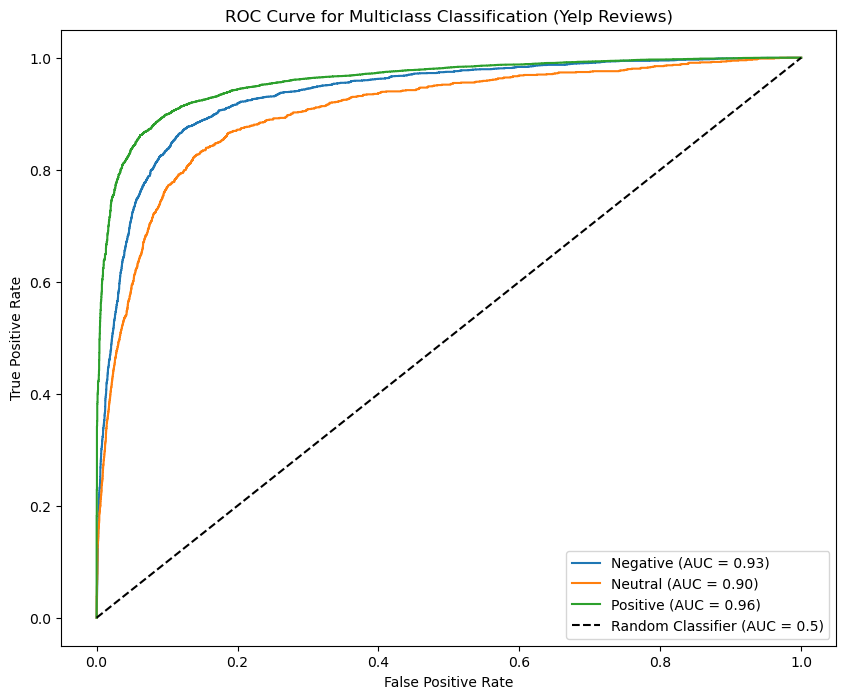

In [55]:
# Get predicted probabilities for each class
y_train_prob = nb_model.predict_proba(X_train_vectors)

# Map classes to indices: Assuming 0=Negative, 1=Neutral, 2=Positive
class_labels = ['Negative', 'Neutral', 'Positive']

# Initialize the plot
plt.figure(figsize=(10, 8))

# Loop through each class and compute ROC curve
for i, label in enumerate(class_labels):
    # Compute the ROC curve for each class
    fpr, tpr, _ = roc_curve(y_train == label, y_train_prob[:, i])
    
    # Compute AUC for the class
    auc_score = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass Classification (Yelp Reviews)')
plt.legend(loc='lower right')

# Show the plot
plt.show()


### Testing Data Check and Evaluation

In [58]:
# Compute F1 Score for all classes
f1_test = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score (Test): {f1_test:.4f}")

Weighted F1 Score (Test): 0.8101


In [60]:
f1_pos_test = f1_score(y_test, y_pred, labels=['Positive'], average='macro')
f1_neg_test = f1_score(y_test, y_pred, labels=['Negative'], average='macro')
f1_neu_test = f1_score(y_test, y_pred, labels=['Neutral'], average='macro')

print(f"F1 Score for Positive (Test): {f1_pos_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_neg_test:.4f}")
print(f"F1 Score for Neutral (Test): {f1_neu_test:.4f}")

F1 Score for Positive (Test): 0.8964
F1 Score for Negative (Test): 0.7340
F1 Score for Neutral (Test): 0.3653


In [64]:
# Get predicted probabilities for all classes
y_test_prob = nb_model.predict_proba(X_test_vectors)

# Compute AUC for each class using 'ovr' or 'ovo'
auc_test = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')
print(f"AUC Score (Test): {auc_test:.4f}")


AUC Score (Test): 0.9047


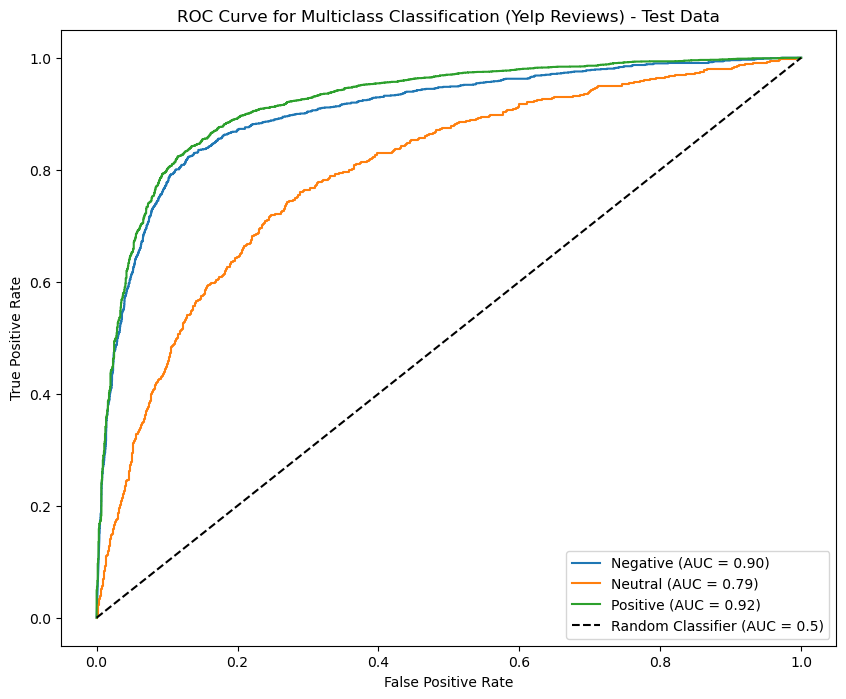

In [66]:
# Get predicted probabilities for testing data
y_test_prob = nb_model.predict_proba(X_test_vectors)

# Initialize the plot
plt.figure(figsize=(10, 8))

# Loop through each class and compute ROC curve
for i, label in enumerate(class_labels):
    # Compute the ROC curve for each class
    fpr, tpr, _ = roc_curve(y_test == label, y_test_prob[:, i])
    
    # Compute AUC for the class
    auc_score = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass Classification (Yelp Reviews) - Test Data')
plt.legend(loc='lower right')

# Show the plot
plt.show()


## Add new features 

In [69]:
# Add new features
df['review_length'] = df['text'].apply(len)  # Length of the review text
df['word_count'] = df['text'].apply(lambda x: len(x.split()))  # Number of words in the review

# Display the updated dataset
df.head()


,text,stars,sentiment,cleaned_text,review_length,word_count
0,We really enjoyed their use of homemade ingredients! Really great meals. A new favorite spot!,5.0,Positive,really enjoyed use homemade ingredient really great meal new favorite spot,93,15
1,"We moved to Sarasota and upon many recommendations decided to go to Tampa to buy furniture. Modani was the store everyone suggested and we were not disappointed.\nJen was fun as well as very professional to work with. We ordered what we needed and subsequently had to cancel an item. No problem. This is a first class operation. Kim, the manager, is so efficient and service-oriented. We look forward to future purchases.",5.0,Positive,moved sarasota upon many recommendation decided go tampa buy furniture modani store everyone suggested disappointed jen fun well professional work ordered needed subsequently cancel item problem first class operation kim manager efficient serviceoriented look forward future purchase,420,72
2,Very disappointed in today's meal. The wife and both got a pasta dish. Both were watered downed and had little to no flavor. My dish was a shrimp and chicken pasta. Had 1 piece of shrimp buried in pasta with the tail still on it. Been coming here over two years. This time I was disappointed.,2.0,Negative,disappointed today meal wife got pasta dish watered downed little flavor dish shrimp chicken pasta piece shrimp buried pasta tail still coming two year time disappointed,293,56
3,"I wish I could reward the store w 5 stars, product with 4 to 5, and the marketing one star! Great service in this location both times I've been (new to AZ). Love the panties. Do not understand the rationale of an online only Labor Day deal complete w signage in store that the associates have to explain doesn't apply in store! You have people in the store that want to spend money and you are telling them to go home to their computers. Foolish! On the 15 min I was in store two customers left unhappy with NO PURCHASE. Feel bad for assoc\n\nUpdate: very unhappy with wear and diff fit between styles. Will keep searching for a brand that works",4.0,Positive,wish could reward store w star product marketing one star great service location time ive new az love panty understand rationale online labor day deal complete w signage store associate explain doesnt apply store people store want spend money telling go home computer foolish min store two customer left unhappy purchase feel bad assoc update unhappy wear diff fit style keep searching brand work,647,122
4,"Came here for brunch yesterday, it goes till 3pm which is great if you are a late riser. We sat at the bar and Angelo was our bartender. Love coming here for brunch and have many times. Normally get the same thing but they have changed brunch menus since I had been in there last. Really missed the Eggs Benedict that is no longer on the new menu :( . To get things started my bf had a few mimosas and I had a Bloody Mary (not pictured). Both delicious and the bloody Mary's come topped with cheese, bacon, pickle, lemon, and lime. It was so tasty I dove right in and forgot to snap a pic, oops! Random but we ordered the Calamari to start food wise. It was great and came with Aioli sauce to dip (which I prefer that or some kind of cheese over marinara). For actual brunch we shared their spin on chicken/waffles and the banana pancakes option. The chicken and waffles was a fried buffalo chicken breast over churros, with a side of ranch to dip. Super good as I love anything buffalo and the way they fried the chicken was delicious. This was definitely all gone before the pancakes were. The banana pancakes were the perfect pairing to be the sweeter side. They had a bourbon creamy sauce poured over, bananas, and powdered sugar, with a cup of syrup. My bf ended up having a few Screw Drivers that he drank right up- loved them. I love coming to bars that have ALOT of options on tap. I was able to have a Blue Moon /Angry Orchard combo that is hard to do som

## Integrate Cross-Validation

In [72]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Initialize the CountVectorizer
vectorizer = CountVectorizer(ngram_range=(1, 1), max_features=10000)
X = vectorizer.fit_transform(df['text'])
y = df['stars'].apply(lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral'))

# Initialize the Naive Bayes model
model = MultinomialNB()

# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy: {cv_scores.mean():.2f}")


Cross-Validation Accuracy: 0.80


## Implement LIME for Local Interpretability

In [75]:
from lime.lime_text import LimeTextExplainer

# Fit the model on the entire dataset
model.fit(X, y)

# Initialize LIME explainer
explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Choose a random review to explain
review_id = 0  # Replace with the index of a review you'd like to interpret
sample_text = df.iloc[review_id]['text']
print(f"Sample Review: {sample_text}")

# Define a wrapper for predict_proba to preprocess text
def predict_proba_wrapper(texts):
    # Vectorize the input text data
    texts_vectorized = vectorizer.transform(texts)
    # Return predictions from the model
    return model.predict_proba(texts_vectorized)

# Use the wrapper with LIME
exp = explainer.explain_instance(
    sample_text,
    predict_proba_wrapper,  # Use the wrapped function
    num_features=10
)

# Visualize the explanation
exp.show_in_notebook(text=True)


Sample Review: We really enjoyed their use of homemade ingredients! Really great meals. A new favorite spot!


## Two interesting findings - wordcloud of positive and negative reviews
## Top 10 positive and Top 10 negative reviews

In [78]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


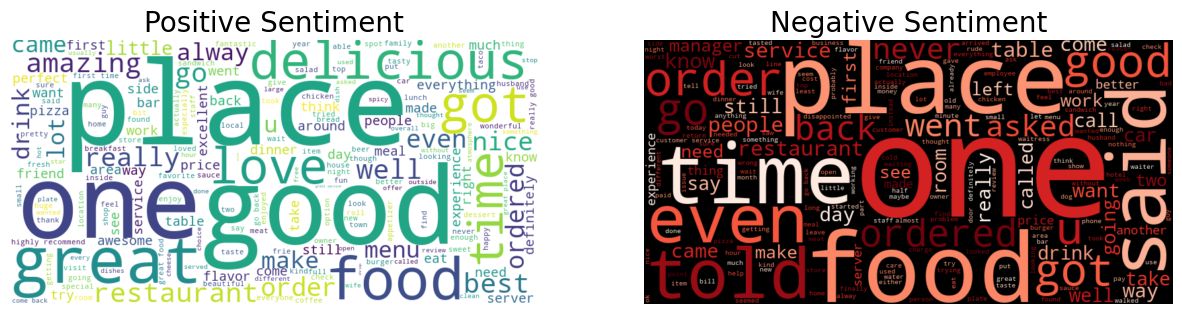

In [80]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import string

# Define stopwords
stop_words = set(stopwords.words('english') + list(string.punctuation))

# Function to preprocess text
def preprocess_text(text):
    tokens = text.lower().split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Filter and preprocess positive reviews
positive_reviews = df[df['stars'] >= 4]['text'].apply(preprocess_text).str.cat(sep=' ')

# Filter and preprocess negative reviews
negative_reviews = df[df['stars'] <= 2]['text'].apply(preprocess_text).str.cat(sep=' ')

# Generate word clouds
positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
negative_wc = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

# Plot word clouds
plt.figure(figsize=(15, 7))

# Positive Word Cloud
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment', fontsize=20)

# Negative Word Cloud
plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Sentiment', fontsize=20)

plt.show()


In [82]:
from collections import Counter

# Function to get top words
def get_top_words(text, n=10):
    # Tokenize the preprocessed text
    tokens = text.split()
    # Count word frequencies
    word_counts = Counter(tokens)
    # Get the top 'n' most common words
    return word_counts.most_common(n)

# Get top 10 words for positive reviews
top_positive = get_top_words(positive_reviews, n=10)

# Get top 10 words for negative reviews
top_negative = get_top_words(negative_reviews, n=10)

# Display results
print("Top 10 Positive Sentiment Words:")
for word, count in top_positive:
    print(f"{word}: {count}")

print("\nTop 10 Negative Sentiment Words:")
for word, count in top_negative:
    print(f"{word}: {count}")


Top 10 Positive Sentiment Words:
great: 6080
food: 4594
place: 4540
good: 4235
get: 3242
like: 3154
one: 3041
really: 2914
also: 2761
would: 2711

Top 10 Negative Sentiment Words:
would: 2085
get: 2056
food: 1976
one: 1923
like: 1849
place: 1547
time: 1491
back: 1394
even: 1380
service: 1376
